In [3]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [4]:
df = pd.read_csv("smartcart_customers.csv")

In [5]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


 Data Preprocessiong 

In [6]:
df["Income"] = df["Income"].fillna(df["Income"].median())

# Feature Enginnerring 

In [7]:
#Age
df["Age"]=2026-df["Year_Birth"]

In [8]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [9]:
#Customer Joing Date
df["Dt_Customer"]= pd .to_datetime(df["Dt_Customer"],dayfirst=True)
reference_date= df["Dt_Customer"].max()
df["Customer_days_Tenure"]=(reference_date-df["Dt_Customer"]).dt.days

In [10]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_days_Tenure
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [11]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_days_Tenure'],
      dtype='object')

In [12]:
#Spending
df["Total_Spendings"]=df["MntWines"] + df['MntFruits']+ df['MntMeatProducts']+df['MntFishProducts']+df["MntSweetProducts"] + df['MntGoldProds']

In [13]:
# Total Children 
df["Total_Children"]=df['Kidhome']+df['Teenhome']

In [14]:
df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_days_Tenure,Total_Spendings,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [15]:
#Education 
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [16]:
df["Education"]=df["Education"].replace({"Basic":"UnderGraduate", "2n Cycle ":"UnderGraduate","Graduation":"Graduate",
                                         "Phd":"Post_Graduation","Master":"Post_Graduation"})

In [17]:
df["Education"].value_counts()

Education
Graduate           1127
PhD                 486
Post_Graduation     370
2n Cycle            203
UnderGraduate        54
Name: count, dtype: int64

In [18]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [19]:
df["Living_With"]=df["Marital_Status"].replace({"Married ":"Partner", "Together  ":"Partner","Single ":"Alone",
   "Divorced ":"Alone","Widow ":"Alone","Absurd":"Alone","YOLO ":"Alone"
})

In [20]:
df["Living_With"].value_counts()

Living_With
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         5
YOLO          2
Name: count, dtype: int64

In [21]:
df["Living_With"] = df["Marital_Status"].replace({
    "Married": "Partner", "Together" : "Partner",
    "Single": "Alone", "Divorced": "Alone",
    "Widow": "Alone", "Absurd": "Alone", "YOLO" : "Alone"
})

In [22]:
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

In [23]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_days_Tenure,Total_Spendings,Total_Children,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


In [24]:
df.columns



Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_days_Tenure',
       'Total_Spendings', 'Total_Children', 'Living_With'],
      dtype='object')

In [25]:
##Drop Coloumns 

cols= ["ID",'Year_Birth','Kidhome','Teenhome','Dt_Customer',"Marital_Status"]
spending_cols= ['MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds']
cols_to_drop=cols+spending_cols

df_cleaned=df.drop(columns=cols_to_drop)

In [26]:
df_cleaned.shape 

(2240, 15)

In [27]:
df.shape


(2240, 27)

# Outliers

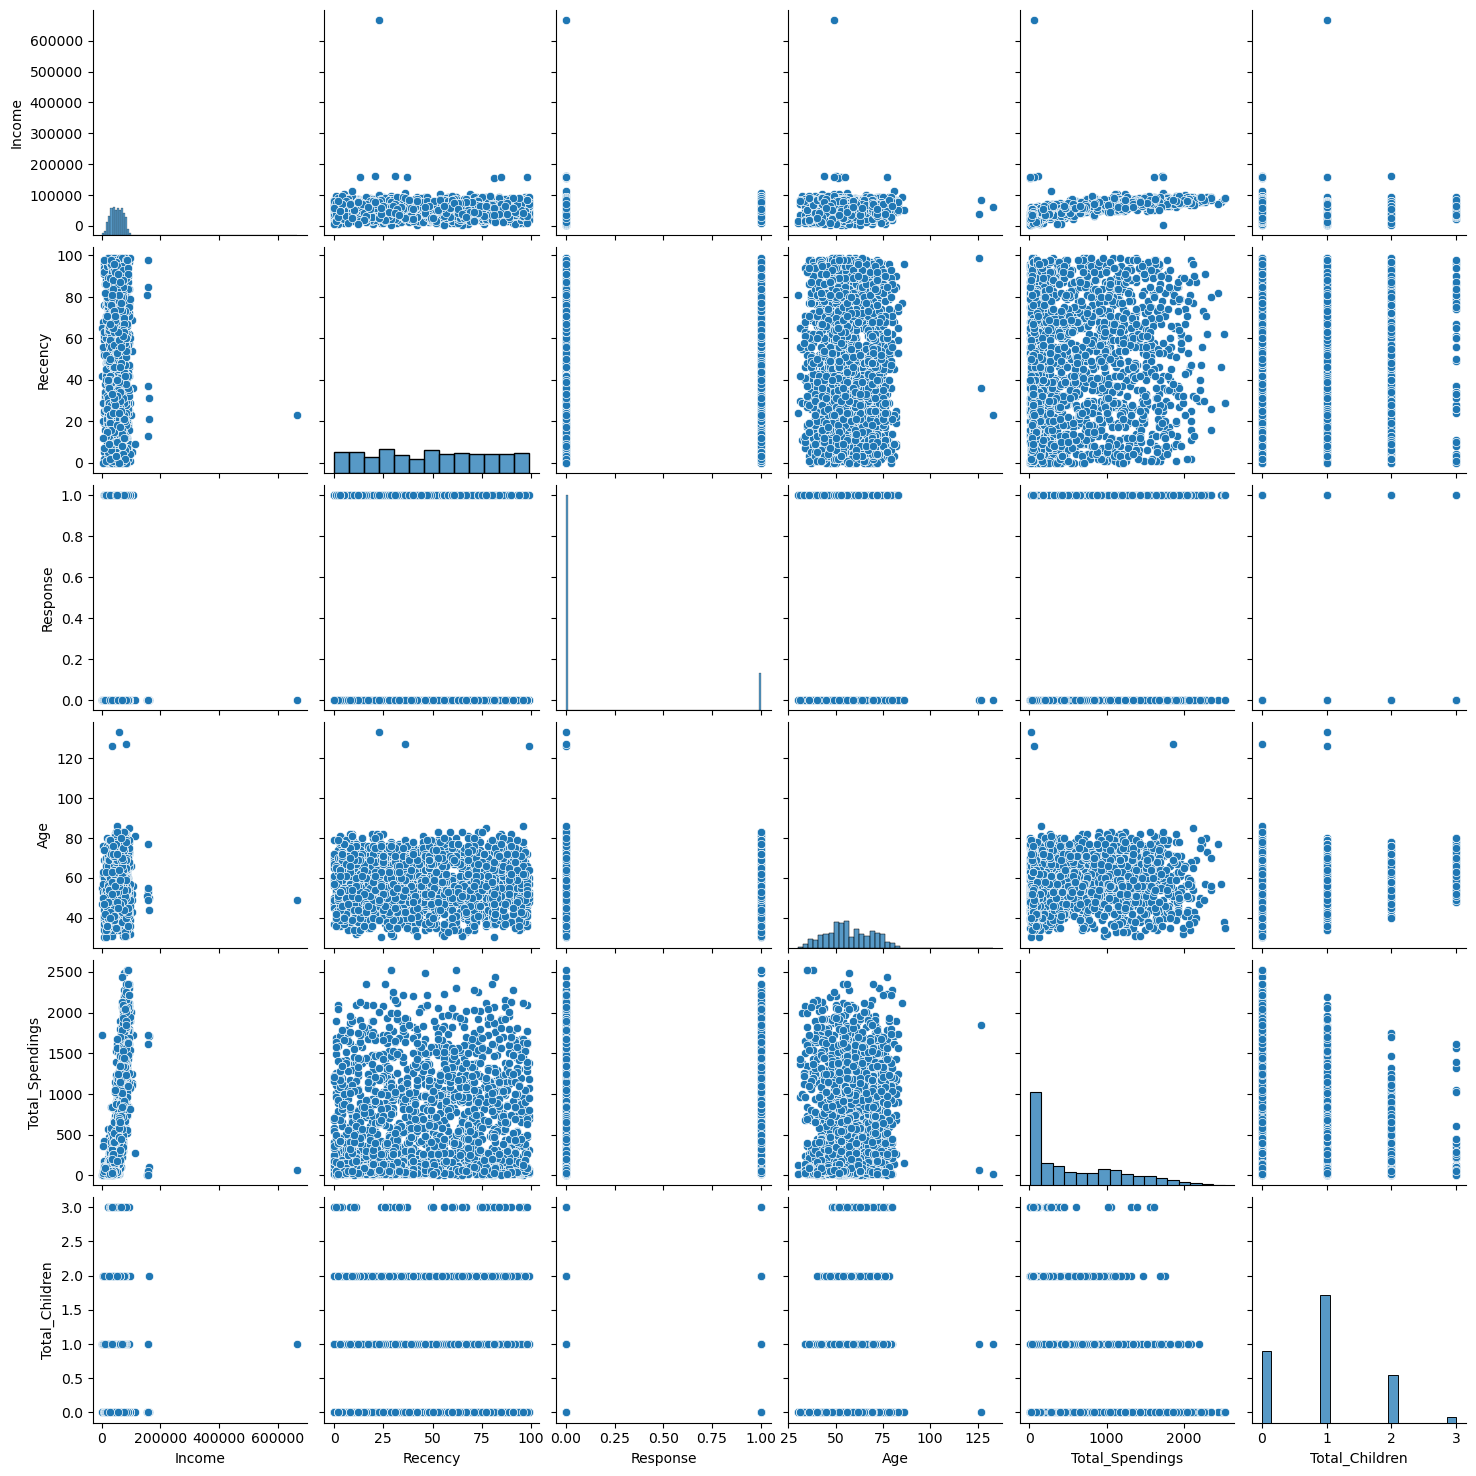

In [28]:
cols=["Income","Recency","Response","Age","Total_Spendings","Total_Children"]
sns.pairplot(df_cleaned[cols])

In [29]:
#Remove Outliers

print("Data size with outliers:",len(df_cleaned))

df_cleaned=df_cleaned[ (df_cleaned["Age"]<90)]
df_cleaned=df_cleaned[ (df_cleaned["Income"]<600_000)]

print("Data size without outliers:",len(df_cleaned))

Data size with outliers: 2240
Data size without outliers: 2236


# Encoding

In [30]:
from sklearn.preprocessing import OneHotEncoder 
ohe=OneHotEncoder() 
cat_cols=["Education","Living_With"]
enc_col=ohe.fit_transform(df_cleaned[cat_cols])


In [31]:
enc_df=pd.DataFrame(enc_col.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)

In [32]:
enc_df.head()

,Education_2n Cycle,Education_Graduate,Education_PhD,Education_Post_Graduation,Education_UnderGraduate,Living_With_Alone,Living_With_Partner
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [33]:
df_encoded=pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [34]:
df_encoded.shape

(2236, 20)

In [35]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_days_Tenure,Total_Spendings,Total_Children,Education_2n Cycle,Education_Graduate,Education_PhD,Education_Post_Graduation,Education_UnderGraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0


# Scaling

In [36]:
from sklearn.preprocessing import  StandardScaler 
X=df_encoded

In [37]:
scaler =  StandardScaler()
X_scaled = scaler.fit_transform(X)

In [38]:
X_scaled 

array([[ 0.28894655,  0.30685572,  0.34873831, ..., -0.15731477,
         1.3476353 , -1.3476353 ],
       [-0.262003  , -0.38397129, -0.16869955, ..., -0.15731477,
         1.3476353 , -1.3476353 ],
       [ 0.91842301, -0.7984675 , -0.68613742, ..., -0.15731477,
        -0.74204052,  0.74204052],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ..., -0.15731477,
         1.3476353 , -1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.15731477,
        -0.74204052,  0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.15731477,
        -0.74204052,  0.74204052]], shape=(2236, 20))

# Visualize 

In [39]:
from sklearn.decomposition import PCA 


In [40]:
pca = PCA(n_components=3)

X_pca=pca.fit_transform(X_scaled)

In [41]:
pca.explained_variance_ratio_

array([0.20935906, 0.10259639, 0.09119891])

/opt/anaconda3/lib/python3.13/site-packages/matplotlib/collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


Text(0.5, 0, 'PCA3')

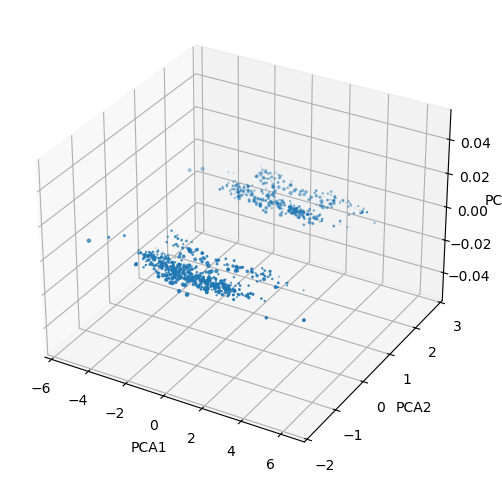

In [42]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")

plt.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")

In [43]:
from sklearn.cluster import KMeans
from kneed import KneeLocator 
wcss=[]
for k in range (1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [44]:
knee = KneeLocator (range(1,11),wcss,curve="convex",direction="decreasing")
optimal_k=knee.elbow

In [45]:
print(optimal_k)

4


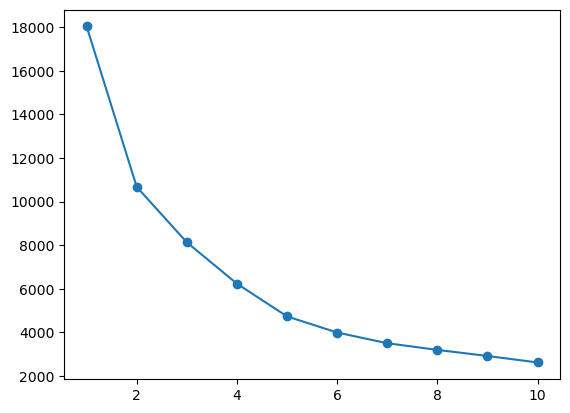

In [46]:
plt.plot(range(1,11),wcss,marker="o")

Text(0, 0.5, 'silouett_score')

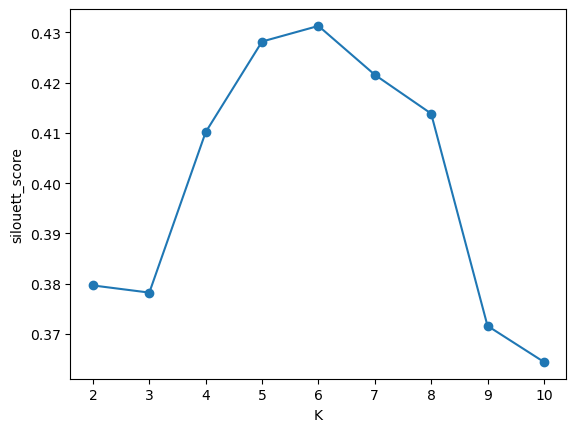

In [54]:
from sklearn.metrics import silhouette_score 

scores=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(X_pca)
    score=silhouette_score(X_pca,labels)
    scores.append(score)

#plot

plt.plot(range(2,11),scores,marker="o")
plt.xlabel("K")
plt.ylabel("silouett_score")

# Clustering 

In [56]:
kmeans=KMeans(n_clusters=4,random_state=42)
labels_kmeans=kmeans.fit_predict(X_pca)

/opt/anaconda3/lib/python3.13/site-packages/matplotlib/collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


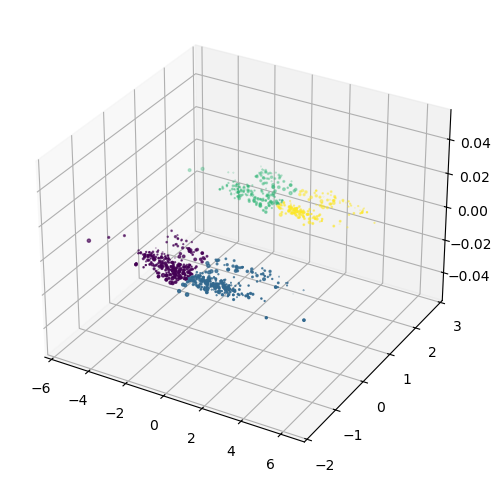

In [57]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")

plt.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_kmeans)

# Agglomerative 

In [59]:
from sklearn.cluster import AgglomerativeClustering 

In [60]:
agg_clf=AgglomerativeClustering (n_clusters=4,linkage="ward")
labels_agg=agg_clf.fit_predict(X_pca)

/opt/anaconda3/lib/python3.13/site-packages/matplotlib/collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


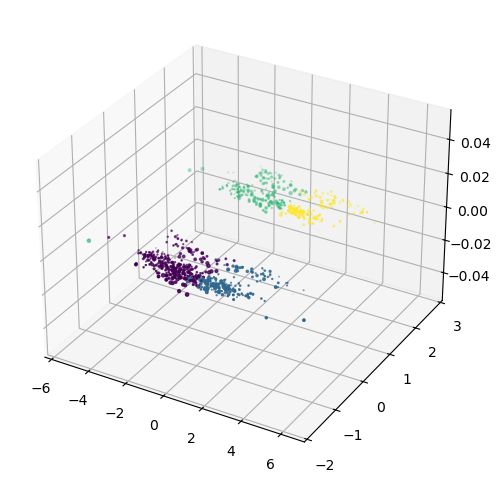

In [61]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")

plt.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_agg)

In [75]:
X["cluster"]=labels_agg

In [76]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,...,Total_Spendings,Total_Children,Education_2n Cycle,Education_Graduate,Education_PhD,Education_Post_Graduation,Education_UnderGraduate,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,...,1617,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,...,27,2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,...,776,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,...,53,1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,...,422,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

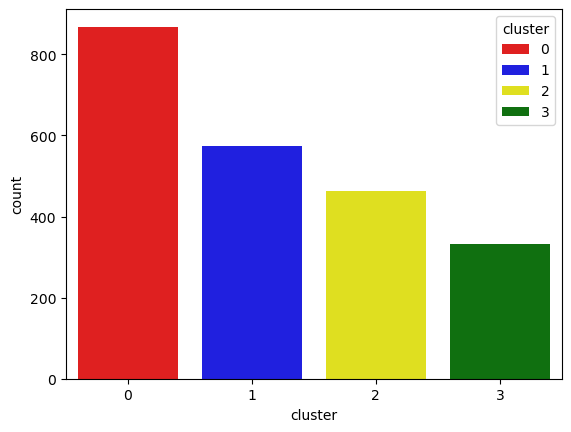

In [77]:
pal=["red","blue","yellow","green"]
sns.countplot(x=X["cluster"],palette=pal,hue=X["cluster"])


<Axes: xlabel='Total_Spendings', ylabel='Income'>

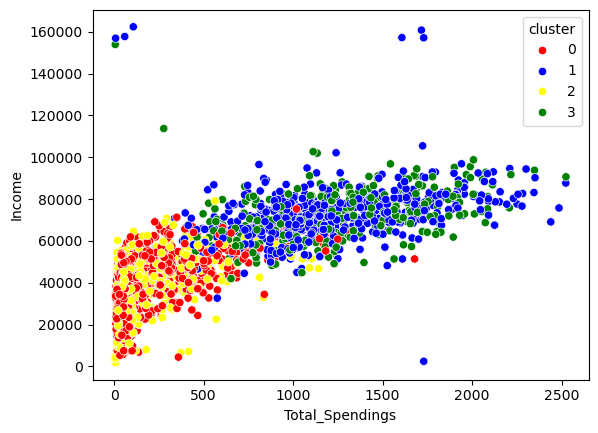

In [78]:
#income and spending pattern 
sns.scatterplot(x=X["Total_Spendings"],y=X["Income"],hue=X["cluster"],palette=pal)

In [79]:
cluster_summary=X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        38561.940668  49.555300           2.644009         3.033410   
1        72131.506981  48.293194           1.919721         5.687609   
2        37869.537797  48.261339           2.600432         2.887689   
3        71775.093373  50.581325           1.813253         5.756024   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.887097           3.972350           6.457373  0.010369   
1                   5.310646           8.598604           3.586387  0.006981   
2                   0.907127           3.799136           6.559395  0.010799   
3                   5.186747           8.509036           3.602410  0.006024   

         Response        Age  Customer_days_Tenure  Total_Spendings  \
cluster        